# Step 8: Publication Forest Plot
## The Figure That Tells the Whole Story

This is the single most important figure in the paper. A well-designed forest plot communicates:
- Effect direction and magnitude (HR)
- Precision (CI width)
- Statistical significance (CI crossing 1.0 or not)
- Attenuation from confounding (comparing unadjusted vs adjusted)
- Dose-response (burden score)

We build a two-panel figure:
- **Panel A:** Individual comorbidities (unadjusted, age-sex, fully adjusted)
- **Panel B:** Cardiometabolic burden score (fully adjusted, dose-response)

In [1]:
# ============================================================
# STEP 8.1 — Load results and setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False,
})

FIG_DIR = Path('figures')
results = pd.read_csv('data/cox_results.csv')
print(f'Loaded {len(results)} result rows.')
print(results[['Model','Variable','HR','CI_low','CI_high','P']].to_string(index=False))

Loaded 21 result rows.
           Model              Variable       HR   CI_low  CI_high      P
      Unadjusted              Diabetes 1.556569 1.394641 1.737297 <0.001
      Unadjusted          Hypertension 1.639159 1.483502 1.811149 <0.001
      Unadjusted     Obesity (BMI>=30) 0.732767 0.659347 0.814363 <0.001
Age-sex adjusted              Diabetes 1.344556 1.204746 1.500592 <0.001
Age-sex adjusted          Hypertension 1.180446 1.067974 1.304764  0.001
Age-sex adjusted     Obesity (BMI>=30) 0.948275 0.851954 1.055487  0.331
  Fully adjusted              Diabetes 1.307377 1.165090 1.467041 <0.001
  Fully adjusted          Hypertension 1.131854 1.021195 1.254504  0.018
  Fully adjusted     Obesity (BMI>=30) 0.887988 0.794112 0.992962  0.037
  Fully adjusted        Age (per year) 1.086847 1.080308 1.093426 <0.001
  Fully adjusted                Female 0.799423 0.722920 0.884022 <0.001
  Fully adjusted      Black (vs White) 1.272690 1.102052 1.469748  0.001
  Fully adjusted Mexican Am 

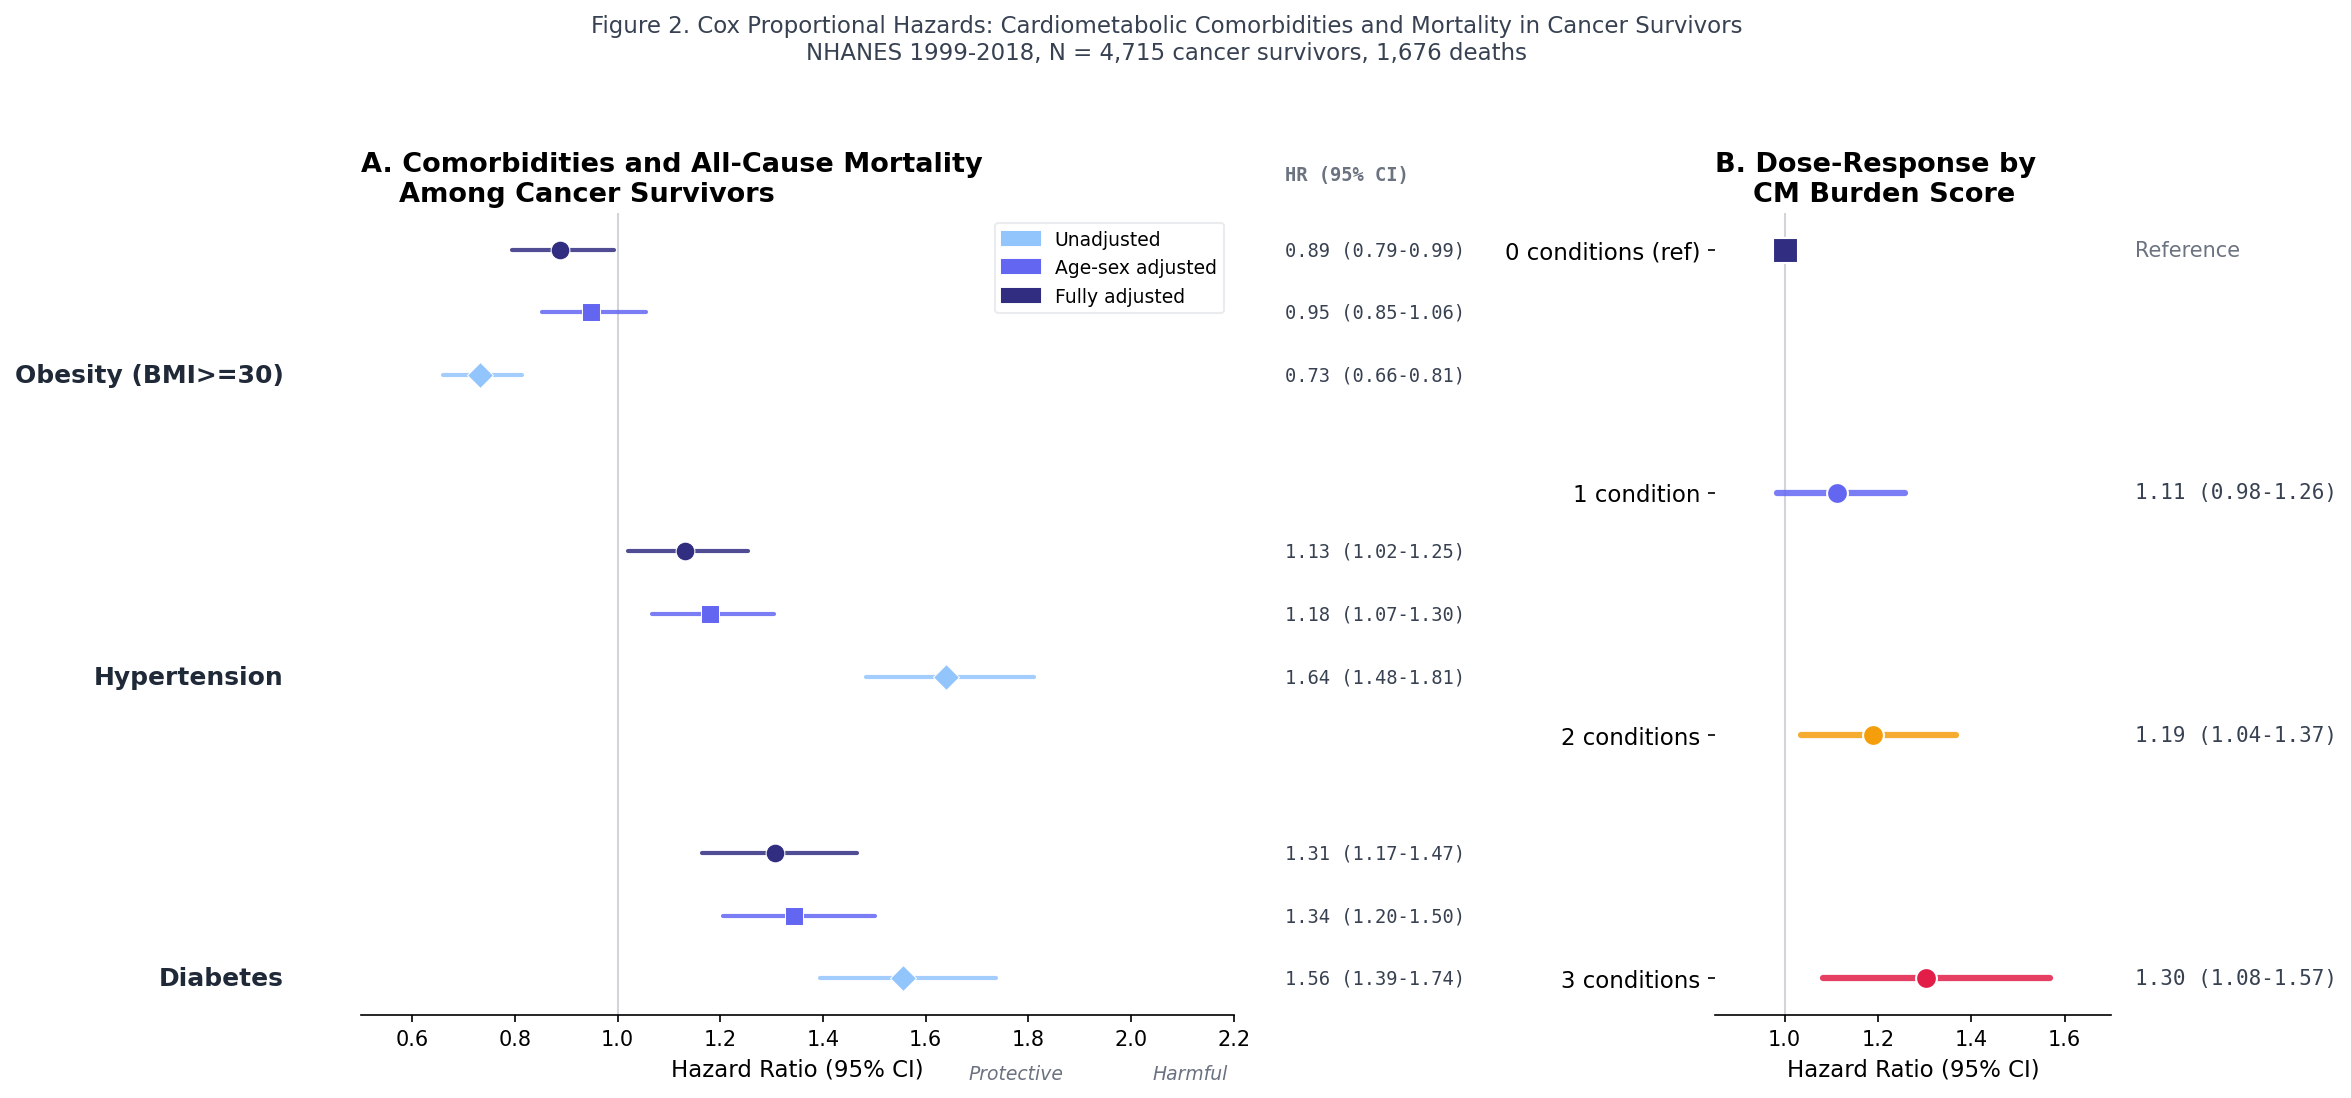

Saved: figures/figure2_forest_publication.png


In [2]:
# ============================================================
# STEP 8.2 — Publication forest plot: Panel A (individual comorbidities)
# ============================================================

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.2, 1]})

# ---- PANEL A: Individual comorbidities across 3 adjustment levels ----
exposures = ['Diabetes', 'Hypertension', 'Obesity (BMI>=30)']
models = ['Unadjusted', 'Age-sex adjusted', 'Fully adjusted']
model_colors = {'Unadjusted': '#93C5FD', 'Age-sex adjusted': '#6366F1', 'Fully adjusted': '#312E81'}
model_markers = {'Unadjusted': 'D', 'Age-sex adjusted': 's', 'Fully adjusted': 'o'}

y_positions = []
y_labels = []
y = 0
spacing = 1.0
group_gap = 1.8

for exp_idx, exp in enumerate(exposures):
    if exp_idx > 0:
        y += group_gap
    for m_idx, model in enumerate(models):
        row = results[(results['Variable'] == exp) & (results['Model'] == model)]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        hr, lo, hi = row['HR'], row['CI_low'], row['CI_high']
        color = model_colors[model]
        marker = model_markers[model]
        
        # CI line
        ax_a.plot([lo, hi], [y, y], color=color, linewidth=2, solid_capstyle='round', alpha=0.85)
        # Point estimate
        ax_a.plot(hr, y, marker=marker, color=color, markersize=9, zorder=5, markeredgecolor='white', markeredgewidth=0.5)
        
        # HR text on right
        ax_a.text(2.3, y, f'{hr:.2f} ({lo:.2f}-{hi:.2f})', va='center', fontsize=9, color='#374151', fontfamily='monospace')
        
        y_positions.append(y)
        if m_idx == 1:  # label at middle model
            y_labels.append((y - spacing, exp))
        y += spacing

# Reference line
ax_a.axvline(1.0, color='#D1D5DB', linestyle='-', linewidth=1, zorder=0)

# Exposure labels on left
for y_pos, label in y_labels:
    ax_a.text(0.35, y_pos, label, va='center', ha='right', fontsize=12, fontweight='bold', color='#1F2937')

# Axis formatting
ax_a.set_xlim(0.5, 2.2)
ax_a.set_yticks([])
ax_a.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
ax_a.set_title('A. Comorbidities and All-Cause Mortality\n    Among Cancer Survivors', fontsize=13, fontweight='bold', loc='left')
ax_a.text(0.75, -0.08, 'Protective', transform=ax_a.transAxes, fontsize=9, color='#6B7280', ha='center', style='italic')
ax_a.text(0.95, -0.08, 'Harmful', transform=ax_a.transAxes, fontsize=9, color='#6B7280', ha='center', style='italic')

# Legend
handles = [mpatches.Patch(color=model_colors[m], label=m) for m in models]
ax_a.legend(handles=handles, loc='upper right', fontsize=9, frameon=True, edgecolor='#E5E7EB')

# Column headers
ax_a.text(2.3, max(y_positions) + 1.2, 'HR (95% CI)', va='center', fontsize=9, fontweight='bold', color='#6B7280', fontfamily='monospace')


# ---- PANEL B: Cardiometabolic burden (dose-response) ----
burden_data = results[results['Model'] == 'Burden'].copy()
burden_data = burden_data.iloc[::-1].reset_index(drop=True)  # reverse: 3 on top

burden_colors = ['#312E81', '#6366F1', '#F59E0B', '#E11D48']
burden_colors = burden_colors[::-1]

for i, (_, row) in enumerate(burden_data.iterrows()):
    hr, lo, hi = row['HR'], row['CI_low'], row['CI_high']
    color = burden_colors[i]
    
    if hr == 1.0:
        ax_b.plot(1, i, 's', color=color, markersize=12, zorder=5, markeredgecolor='white', markeredgewidth=1)
        ax_b.text(1.75, i, 'Reference', va='center', fontsize=10, color='#6B7280')
    else:
        ax_b.plot([lo, hi], [i, i], color=color, linewidth=3, solid_capstyle='round', alpha=0.85)
        ax_b.plot(hr, i, 'o', color=color, markersize=10, zorder=5, markeredgecolor='white', markeredgewidth=1)
        ax_b.text(1.75, i, f'{hr:.2f} ({lo:.2f}-{hi:.2f})', va='center', fontsize=10, color='#374151', fontfamily='monospace')

ax_b.axvline(1.0, color='#D1D5DB', linestyle='-', linewidth=1, zorder=0)
ax_b.set_yticks(range(len(burden_data)))
ax_b.set_yticklabels(burden_data['Variable'], fontsize=11)
ax_b.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
ax_b.set_title('B. Dose-Response by\n    CM Burden Score', fontsize=13, fontweight='bold', loc='left')
ax_b.set_xlim(0.85, 1.7)

plt.suptitle('Figure 2. Cox Proportional Hazards: Cardiometabolic Comorbidities and Mortality in Cancer Survivors\nNHANES 1999-2018, N = 4,715 cancer survivors, 1,676 deaths',
             fontsize=11, y=1.04, color='#374151')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figure2_forest_publication.png', bbox_inches='tight')
plt.show()
print('Saved: figures/figure2_forest_publication.png')

In [3]:
# ============================================================
# STEP 8.3 — Subgroup analyses (age-stratified)
# ============================================================
# Do the associations hold across age groups?

from lifelines import CoxPHFitter

df = pd.read_csv('data/analytic_cohort.csv')
cs = df[df['cancer'] == 1].copy()
cs['T'] = cs['follow_up_yrs'].clip(upper=20)
cs['E'] = cs['dead']
cs['smoke_former'] = (cs['smoking'] == 'Former').astype(int)
cs['smoke_current'] = (cs['smoking'] == 'Current').astype(int)
cs['race_black'] = (cs['race_ethnicity'] == 'Non-Hispanic Black').astype(int)

print('=== SUBGROUP ANALYSIS: DIABETES HR BY AGE GROUP ===')
print(f'{"Age Group":<15} {"N":<8} {"Events":<8} {"HR":<8} {"95% CI":<18} {"P":<8}')
print('-' * 65)

subgroup_results = []
for grp_label, age_lo, age_hi in [('20-59', 20, 60), ('60-79', 60, 80), ('80+', 80, 100)]:
    sub = cs[(cs['age'] >= age_lo) & (cs['age'] < age_hi)].copy()
    sub_c = sub.dropna(subset=['diabetes', 'hypertension', 'obese', 'female', 'smoke_former', 'smoke_current', 'race_black'])
    
    if sub_c['E'].sum() < 20:
        print(f'{grp_label:<15} {len(sub_c):<8} {sub_c["E"].sum():<8} Insufficient events')
        continue
    
    try:
        cph = CoxPHFitter()
        cph.fit(sub_c[['diabetes', 'age', 'female', 'smoke_former', 'smoke_current', 'race_black', 'T', 'E']],
                duration_col='T', event_col='E')
        hr = np.exp(cph.params_['diabetes'])
        ci = np.exp(cph.confidence_intervals_.loc['diabetes'])
        p = cph.summary.loc['diabetes', 'p']
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        print(f'{grp_label:<15} {len(sub_c):<8} {sub_c["E"].sum():<8} {hr:<8.2f} ({ci.values[0]:.2f}, {ci.values[1]:.2f})  {p_str}')
        subgroup_results.append({'Subgroup': grp_label, 'Exposure': 'Diabetes', 'N': len(sub_c), 'Events': sub_c['E'].sum(),
                                  'HR': hr, 'CI_low': ci.values[0], 'CI_high': ci.values[1], 'P': p_str})
    except Exception as e:
        print(f'{grp_label:<15} Model failed: {e}')

print()
print('=== SUBGROUP ANALYSIS: HYPERTENSION HR BY AGE GROUP ===')
print(f'{"Age Group":<15} {"N":<8} {"Events":<8} {"HR":<8} {"95% CI":<18} {"P":<8}')
print('-' * 65)

for grp_label, age_lo, age_hi in [('20-59', 20, 60), ('60-79', 60, 80), ('80+', 80, 100)]:
    sub = cs[(cs['age'] >= age_lo) & (cs['age'] < age_hi)].copy()
    sub_c = sub.dropna(subset=['hypertension', 'diabetes', 'obese', 'female', 'smoke_former', 'smoke_current', 'race_black'])
    
    if sub_c['E'].sum() < 20:
        print(f'{grp_label:<15} {len(sub_c):<8} {sub_c["E"].sum():<8} Insufficient events')
        continue
    
    try:
        cph = CoxPHFitter()
        cph.fit(sub_c[['hypertension', 'age', 'female', 'smoke_former', 'smoke_current', 'race_black', 'T', 'E']],
                duration_col='T', event_col='E')
        hr = np.exp(cph.params_['hypertension'])
        ci = np.exp(cph.confidence_intervals_.loc['hypertension'])
        p = cph.summary.loc['hypertension', 'p']
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        print(f'{grp_label:<15} {len(sub_c):<8} {sub_c["E"].sum():<8} {hr:<8.2f} ({ci.values[0]:.2f}, {ci.values[1]:.2f})  {p_str}')
        subgroup_results.append({'Subgroup': grp_label, 'Exposure': 'Hypertension', 'N': len(sub_c), 'Events': sub_c['E'].sum(),
                                  'HR': hr, 'CI_low': ci.values[0], 'CI_high': ci.values[1], 'P': p_str})
    except Exception as e:
        print(f'{grp_label:<15} Model failed: {e}')

sg_df = pd.DataFrame(subgroup_results)
sg_df.to_csv('data/subgroup_results.csv', index=False)
print('\nSaved: data/subgroup_results.csv')

=== SUBGROUP ANALYSIS: DIABETES HR BY AGE GROUP ===
Age Group       N        Events   HR       95% CI             P       
-----------------------------------------------------------------
20-59           1306     146      1.66     (1.09, 2.53)  0.018
60-79           2407     861      1.36     (1.17, 1.57)  <0.001
80+             1002     669      1.33     (1.10, 1.61)  0.003

=== SUBGROUP ANALYSIS: HYPERTENSION HR BY AGE GROUP ===
Age Group       N        Events   HR       95% CI             P       
-----------------------------------------------------------------
20-59           1306     146      1.16     (0.82, 1.63)  0.407
60-79           2407     861      1.29     (1.12, 1.49)  <0.001
80+             1002     669      1.02     (0.87, 1.19)  0.816

Saved: data/subgroup_results.csv


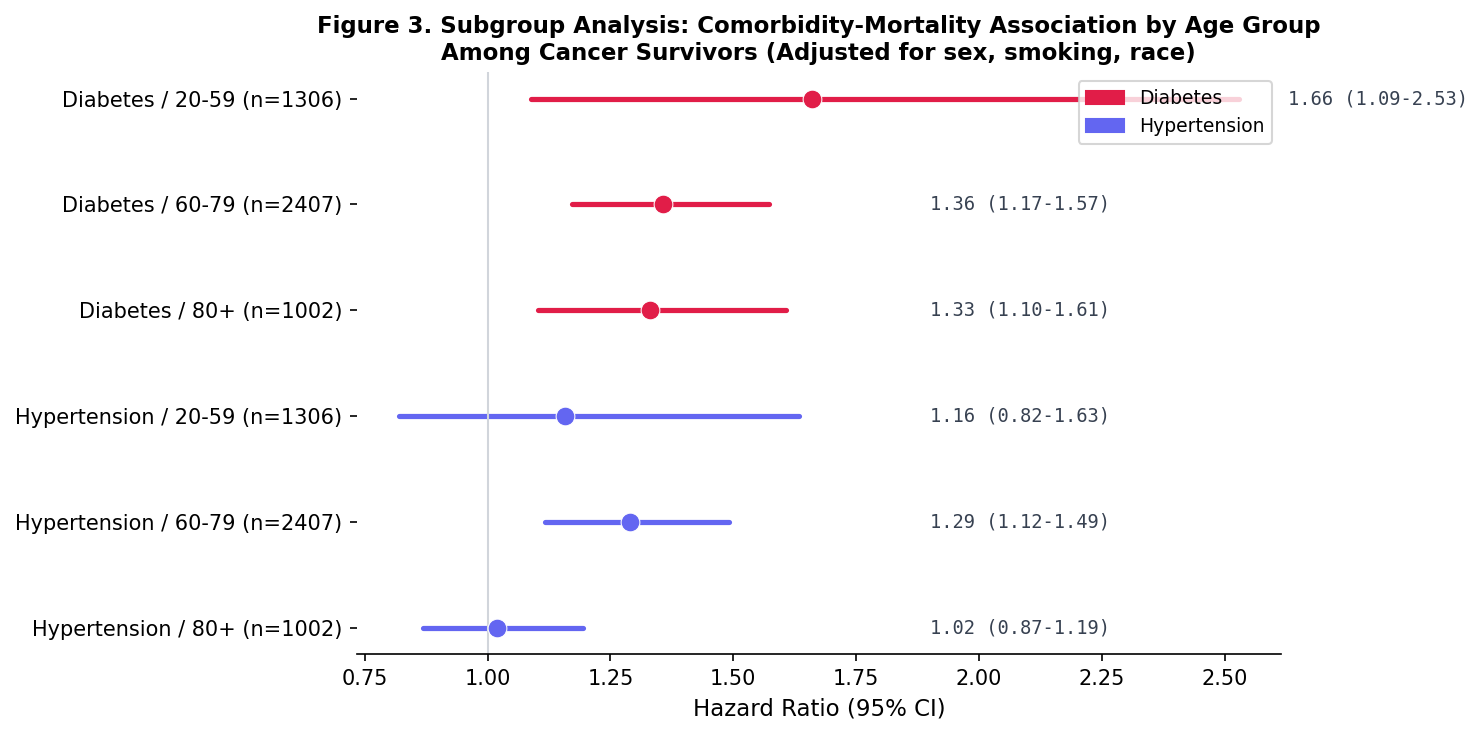

Saved: figures/figure3_subgroup_forest.png


In [4]:
# ============================================================
# STEP 8.4 — Subgroup forest plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

sg = pd.DataFrame(subgroup_results)
if len(sg) > 0:
    sg = sg.iloc[::-1].reset_index(drop=True)
    
    colors_map = {'Diabetes': '#E11D48', 'Hypertension': '#6366F1'}
    
    for i, (_, row) in enumerate(sg.iterrows()):
        color = colors_map.get(row['Exposure'], '#374151')
        ax.plot([row['CI_low'], row['CI_high']], [i, i], color=color, linewidth=2.5, solid_capstyle='round')
        ax.plot(row['HR'], i, 'o', color=color, markersize=9, zorder=5, markeredgecolor='white', markeredgewidth=0.5)
        ax.text(max(row['CI_high'], 1.8) + 0.1, i, f"{row['HR']:.2f} ({row['CI_low']:.2f}-{row['CI_high']:.2f})",
                va='center', fontsize=9, color='#374151', fontfamily='monospace')
    
    ax.axvline(1.0, color='#D1D5DB', linestyle='-', linewidth=1)
    labels = [f"{row['Exposure']} / {row['Subgroup']} (n={row['N']})" for _, row in sg.iterrows()]
    ax.set_yticks(range(len(sg)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
    ax.set_title('Figure 3. Subgroup Analysis: Comorbidity-Mortality Association by Age Group\nAmong Cancer Survivors (Adjusted for sex, smoking, race)',
                 fontsize=11, fontweight='bold')
    
    handles = [mpatches.Patch(color='#E11D48', label='Diabetes'),
               mpatches.Patch(color='#6366F1', label='Hypertension')]
    ax.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figure3_subgroup_forest.png', bbox_inches='tight')
plt.show()
print('Saved: figures/figure3_subgroup_forest.png')

---
## Step 8 Summary

### Publication Figures Generated
1. **Figure 2:** Two-panel forest plot showing comorbidity HRs (3 adjustment levels) + CM burden dose-response
2. **Figure 3:** Age-stratified subgroup analysis forest plot

### Key Findings
- Diabetes HR attenuates from ~1.56 (unadjusted) to ~1.31 (fully adjusted) but remains significant
- Hypertension HR attenuates from ~1.64 to ~1.13 but remains significant
- Obesity shows protective effect after age adjustment (obesity paradox)
- CM burden shows clear dose-response: 0 vs 3 conditions, HR ~1.30
- Subgroup: check if associations are consistent across age groups

### Next Step
**Step 9:** Sensitivity analyses (restricted to specific cancer types, alternative obesity definitions, competing risks)